# Análisis EDA y Clasificación de Tickets de Requerimientos Bancarios

Este notebook realiza un análisis exploratorio de datos (EDA) y un modelo de clasificación para predecir la categoría de cada ticket de requerimientos bancarios a partir de un archivo CSV.

## 1. Carga de Librerías y Configuración Inicial

In [42]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import re
import unicodedata
import warnings
from collections import Counter

# ── Datos y visualización ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Estadística y matrices dispersas ─────────────────────────────────────────
from scipy.stats import f_oneway
from scipy.sparse import vstack

# ── Scikit-learn: features y preprocesamiento ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-learn: modelos ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: selección de modelos y métricas ────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

# ── Configuración de gráficos ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})


## 2. Carga y Exploración Inicial de Datos

In [43]:
# Cargar el archivo CSV
# Ruta relativa desde Analisis/ hacia Datos/ (un nivel arriba)
ruta_csv = os.path.join(os.path.dirname(os.getcwd()), 'Datos', 'RequerimientosCategorizados_v1.csv')
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

# Intenta cargar el archivo
try:
    try:
        df = pd.read_csv(ruta_csv, sep=';', encoding='latin-1')
        if len(df.columns) == 1:
            raise ValueError('Wrong delimiter')
    except (ValueError, pd.errors.ParserError):
        df = pd.read_csv(ruta_csv, sep=',', encoding='latin-1')
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)

df.head()


Directorio actual: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\Entrenamiento\Semisupervisado
Ruta CSV: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\Entrenamiento\Datos\RequerimientosCategorizados_v1.csv
Dimensiones: (9606, 14)


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,fecha_asignacion,clasificacion
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,ÂEstimados su gentil ayuda con el cambio de e...,2025-02-16,chequeras_gestion_rangos
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,Â¿CÃ³mo se genera la informaciÃ³n del archivo ...,2026-02-06,debito_automatico_pagos
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,Â¿Buenos dÃ­as por favor su ayuda con revisiÃ³...,2025-12-06,cheques_activos_devolucion
3,RITM0795775,Cerrado,DAYANA PAMELA PORTILLA ROMAN,falso,dapporti@pichincha.com,ANALISTA UNIDAD ATENCION AL CLIENTE,Banco Pichincha C.A.,ARCHANA DUBEY,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,]Estimado su gentil apoyo con el pedido del cl...,2025-08-16,facturacion_comisiones_bancarias
4,RITM0424331,Cerrado,VICTOR HENRY SALINAS AGUIRRE,falso,visalina@pichincha.com,ARQUITECTO EMPRESARIAL EXPERTO,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,[Iniciativa Multi Core] - ConfiguraciÃ³n de Cu...,2025-08-13,iniciativas


In [44]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 9606 entries, 0 to 9605
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   number                         9606 non-null   str  
 1   state                          9606 non-null   str  
 2   ref_sc_req_item.requested_for  9605 non-null   str  
 3   requested_for.vip              9606 non-null   str  
 4   requested_for.email            9604 non-null   str  
 5   requested_for.title            9604 non-null   str  
 6   requested_for.company          9604 non-null   str  
 7   assigned_to                    9530 non-null   str  
 8   assignment_group               9606 non-null   str  
 9   short_description              9606 non-null   str  
 10  cat_item.sc_catalogs           9605 non-null   str  
 11  description                    9604 non-null   str  
 12  fecha_asignacion               9606 non-null   str  
 13  clasificacion                

assigned_to                      76
requested_for.email               2
requested_for.company             2
description                       2
requested_for.title               2
ref_sc_req_item.requested_for     1
cat_item.sc_catalogs              1
requested_for.vip                 0
number                            0
state                             0
short_description                 0
assignment_group                  0
fecha_asignacion                  0
clasificacion                     0
dtype: int64

In [45]:
# Exploración rápida de variables informativas
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)



Porcentaje de valores nulos por columna:
assigned_to                      0.791172
requested_for.email              0.020820
requested_for.company            0.020820
description                      0.020820
requested_for.title              0.020820
ref_sc_req_item.requested_for    0.010410
cat_item.sc_catalogs             0.010410
requested_for.vip                0.000000
number                           0.000000
state                            0.000000
short_description                0.000000
assignment_group                 0.000000
fecha_asignacion                 0.000000
clasificacion                    0.000000
dtype: float64

Número de valores únicos por columna:
number                           9601
description                      8990
requested_for.email              1678
ref_sc_req_item.requested_for    1672
fecha_asignacion                  524
requested_for.title               215
assigned_to                        40
clasificacion                      32
short_descri

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [46]:
# Cambiar el nombre de la columna 'Categoria' por 'Clasificación'
df = df.rename(columns={"clasificacion": "Clasificación"})

In [47]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
formas_numeradas                      730
cheques_activos_devolucion            705
chequeras_gestion_rangos              614
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              437
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       251
revision                              234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           188
debito_automatico_pagos               182
consolidacion_produc

In [48]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[          'chequeras_gestion_rangos',            'debito_automatico_pagos',
         'cheques_activos_devolucion',   'facturacion_comisiones_bancarias',
                        'iniciativas',         'banca_empresas_movimientos',
     'glif_journal_contabilidad_test',                     'soporte_tablas',
                 'archivos_sftp_test',   'soporte_transacciones_produccion',
        'cuentas_ahorro_reactivacion',         'soporte_transacciones_test',
               'motor_transferencias', 'comprobantes_pignoracion_impresion',
         'inversiones_intereses_mora',         'gestion_cuentas_activacion',
                     'estados_cuenta',              'mt940_swift_extractos',
   'operaciones_credito_amortizacion',           'opciones_menu_bancslinks',
       'ambientes_test_integraciones',                   'formas_numeradas',
    'cheques_emergencia_certificados',        'incidencias_repost_castigos',
        'incidencias_cuentas_

In [49]:
# Normalización de valores en la columna 'Clasificación'
def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")


Valores únicos en Clasificación: <StringArray>
[          'chequeras_gestion_rangos',            'debito_automatico_pagos',
         'cheques_activos_devolucion',   'facturacion_comisiones_bancarias',
                        'iniciativas',         'banca_empresas_movimientos',
     'glif_journal_contabilidad_test',                     'soporte_tablas',
                 'archivos_sftp_test',   'soporte_transacciones_produccion',
        'cuentas_ahorro_reactivacion',         'soporte_transacciones_test',
               'motor_transferencias', 'comprobantes_pignoracion_impresion',
         'inversiones_intereses_mora',         'gestion_cuentas_activacion',
                     'estados_cuenta',              'mt940_swift_extractos',
   'operaciones_credito_amortizacion',           'opciones_menu_bancslinks',
       'ambientes_test_integraciones',                   'formas_numeradas',
    'cheques_emergencia_certificados',        'incidencias_repost_castigos',
        'incidencias_cuentas_

In [50]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [51]:
# Reemplazar valores sin clasificar y pendientes → sin_clasificar
df['Clasificación'] = df['Clasificación'].replace(
    ['0', 0, None, np.nan, 'no aplica', 'pendiente'],
    'sin_clasificar'
)

# Eliminar filas con clases que tienen muy pocos ejemplos para entrenar (< 3)
clases_a_eliminar = ['cc-cancelacion batch', 'cc-evento-alerta']
filas_antes = len(df)
df = df[~df['Clasificación'].isin(clases_a_eliminar)].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)}  ({clases_a_eliminar})")
print(f"Total filas restantes: {len(df)}")


Filas eliminadas: 0  (['cc-cancelacion batch', 'cc-evento-alerta'])
Total filas restantes: 9606


In [52]:
# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())


<StringArray>
[          'chequeras_gestion_rangos',            'debito_automatico_pagos',
         'cheques_activos_devolucion',   'facturacion_comisiones_bancarias',
                        'iniciativas',         'banca_empresas_movimientos',
     'glif_journal_contabilidad_test',                     'soporte_tablas',
                 'archivos_sftp_test',   'soporte_transacciones_produccion',
        'cuentas_ahorro_reactivacion',         'soporte_transacciones_test',
               'motor_transferencias', 'comprobantes_pignoracion_impresion',
         'inversiones_intereses_mora',         'gestion_cuentas_activacion',
                     'estados_cuenta',              'mt940_swift_extractos',
   'operaciones_credito_amortizacion',           'opciones_menu_bancslinks',
       'ambientes_test_integraciones',                   'formas_numeradas',
    'cheques_emergencia_certificados',        'incidencias_repost_castigos',
        'incidencias_cuentas_modulos',  'certificados_deposito

In [53]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(f"Total de clases de Clasificación: {conteo_clases.shape[0]}")
print()
print(conteo_clases)


Total de clases de Clasificación: 32

Clasificación
formas_numeradas                      730
cheques_activos_devolucion            705
chequeras_gestion_rangos              614
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              437
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       251
revision                              234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           188
debito_automatico_pagos 

In [54]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 4


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,fecha_asignacion,Clasificación
9601,RITM0978773,Nuevo,CARLA LIZETH MORA LEON,falso,clmora@pichincha.com,OFICIAL COMERCIAL Y SERVICIOS,Banco Pichincha C.A.,IABASTIC,cheques_activos_devolucion,Requerimientos de información relacionados a B...,TI,POR FAVOR SU GENTIL AYUDA CON EL DEBITO O INF...,22/07/2026 16:14:48,cheques_activos_devolucion
9602,RITM0978842,Nuevo,FERNANDO GIOVANNY MORALES NACATO,falso,fermoral@pichincha.com,EJECUTIVO SERVICIOS TRANSACCIONALES SR,Banco Pichincha C.A.,MYZUNIGA,cheques_emergencia_certificados,Requerimientos de información relacionados a B...,TI,"Estimados buenas tardes, Favor su gentil ayuda...",22/07/2026 16:45:18,cheques_emergencia_certificados
9603,RITM0978723,Nuevo,DIEGO PAUL AGUAS ALMEIDA,falso,daguas@pichincha.com,ADMINISTRADOR SERVICIOS,Banco Pichincha C.A.,LSCATOTA,cuentas_ahorro_reactivacion,Requerimientos de información relacionados a B...,TI,Estimados buenas tardes por favor su ayuda con...,22/07/2026 15:55:48,cuentas_ahorro_reactivacion
9605,RITM0978854,Nuevo,JENIFFER ALEXANDRA RONQUILLO ORTEGA,falso,jaronqui@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,BARODRIG,chequeras_gestion_rangos,Requerimientos de información relacionados a B...,TI,FAVOR SU AYUDA CON CAMBIO DE CENTRO DE COSTO C...,22/07/2026 16:48:41,chequeras_gestion_rangos


## 4. Análisis Exploratorio de Datos (EDA)


--- assignment_group ---


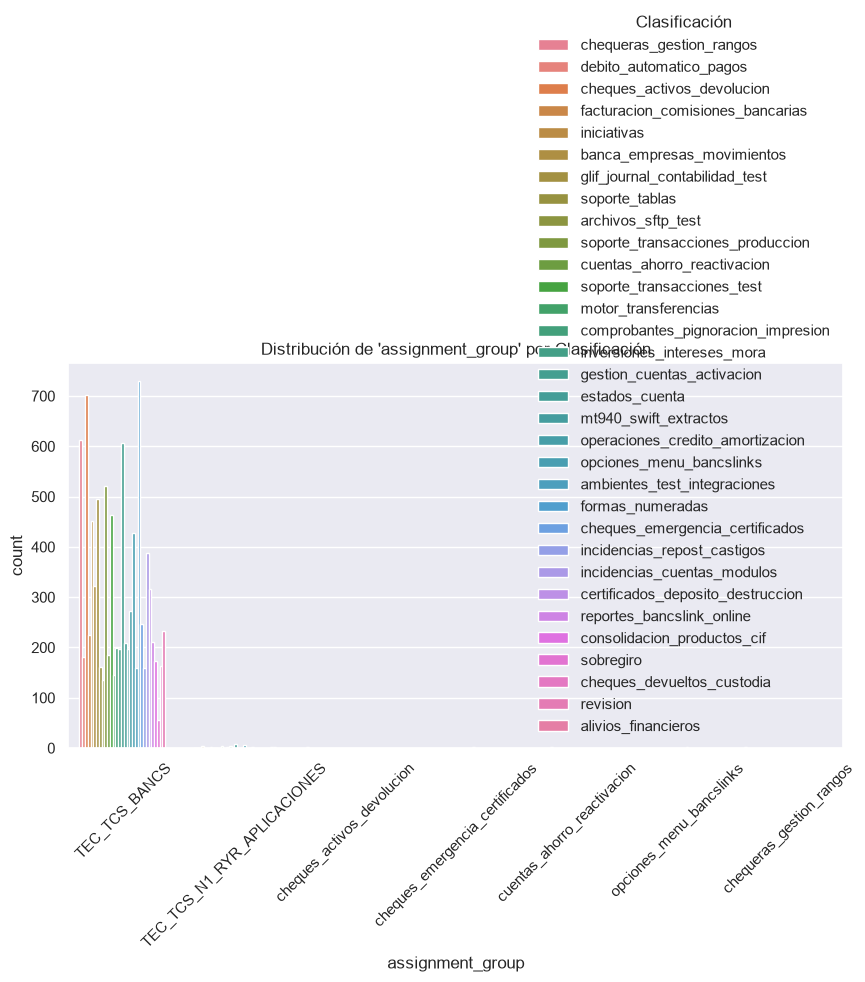

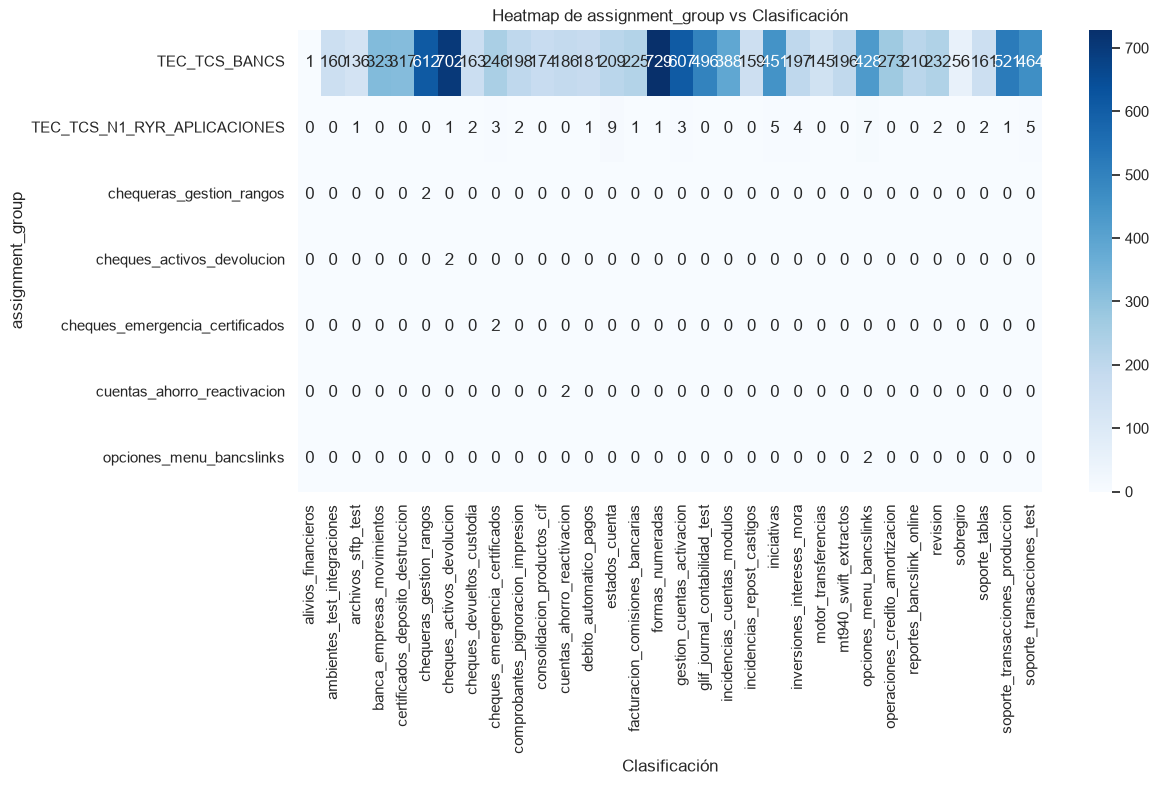

In [55]:
# Gráficos de barras apiladas y heatmaps para columnas categóricas relevantes
columnas_categoricas = [
    'priority', 'severity', 'contact_type', 'assignment_group', 'Origen', 'Ambiente',
    'u_subcategory', 'u_subcategory_2'
]

for col in columnas_categoricas:
    if col in df.columns and df[col].nunique() > 1 and df[col].nunique() < 25:
        print(f"\n--- {col} ---")
        # Gráfico de barras apiladas
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, hue='Clasificación', order=df[col].value_counts().index)
        plt.title(f"Distribución de '{col}' por Clasificación")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Heatmap de la tabla de contingencia
        tabla = pd.crosstab(df[col], df['Clasificación'])
        plt.figure(figsize=(12, 6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de {col} vs Clasificación")
        plt.show()


In [56]:
# 2. Variables numéricas vs. Clasificación (ANOVA y boxplots)
# Recomputar columnas_informativas sobre el df ya renombrado (sin 'Categoría')
columnas_informativas = [
    col for col in df.columns
    if df[col].nunique() > 1
    and df[col].nunique() < df.shape[0] * 0.9
    and not col.lower().startswith('id')
]

num_vars = [col for col in columnas_informativas if df[col].dtype in ['int64', 'float64']]
for col in num_vars:
    print(f"\nBoxplot y ANOVA: {col} vs Clasificación")
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='Clasificación', y=col)
    plt.title(f"Distribución de '{col}' por Clasificación")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # ANOVA solo si hay más de un grupo
    grupos = [g[1] for g in df.groupby('Clasificación')[col] if len(g[1]) > 1]
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"p-valor ANOVA: {p:.4f}")


## 5. Preparación de Datos para Modelado

In [57]:
# Cargar stopwords ANTES de limpiar_texto para poder usarlas en la limpieza
nltk.download('stopwords', quiet=True)
spanish_stopwords = set(stopwords.words('spanish'))
print(f"✓ Stopwords cargadas: {len(spanish_stopwords)} palabras")


✓ Stopwords cargadas: 313 palabras


In [58]:
# Unificar texto relevante para análisis de similitud
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('')
)
# Guardar copia del texto crudo ANTES de limpiar (para análisis de duplicados)
df['texto_unificado_raw'] = df['texto_unificado']


In [59]:
# ── Análisis de duplicados exactos en texto_unificado (PRE-limpieza) ──────────
# Usa texto_unificado_raw para que sea robusto sin importar el orden de ejecución.

dup_mask_raw = df['texto_unificado_raw'].duplicated(keep=False)
df_dups_raw = df[dup_mask_raw].copy()

print(f"Tickets con texto_unificado duplicado (crudo): {dup_mask_raw.sum()}  "
      f"({dup_mask_raw.mean():.1%} del total)")
print(f"Textos únicos que se repiten: {df_dups_raw['texto_unificado_raw'].nunique()}")

# Tabla de frecuencias: cuántas veces se repite cada texto y sus clasificaciones
resumen_dups = (
    df_dups_raw
    .groupby('texto_unificado_raw', as_index=False)
    .agg(
        n_tickets       = ('number', 'count'),
        clasificaciones = ('Clasificación', lambda x: ', '.join(sorted(x.unique()))),
        n_clases        = ('Clasificación', 'nunique'),
        ejemplos        = ('number', lambda x: ', '.join(x.head(4).astype(str)))
    )
    .rename(columns={'texto_unificado_raw': 'texto_unificado'})
    .sort_values('n_tickets', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 textos más repetidos:")
with pd.option_context('display.max_colwidth', 80):
    display(resumen_dups.head(20))

# Duplicados con clasificaciones distintas (ambigüedad real)
ambiguos = resumen_dups[resumen_dups['n_clases'] > 1]
print(f"\nTextos duplicados con DISTINTAS clasificaciones (ambigüedad): {len(ambiguos)}")
if len(ambiguos):
    with pd.option_context('display.max_colwidth', 80):
        display(ambiguos.head(20))


Tickets con texto_unificado duplicado (crudo): 906  (9.4% del total)
Textos únicos que se repiten: 304

Top 20 textos más repetidos:


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
0,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Motor de Tra...,50,motor_transferencias,1,"RITM0688742, RITM0686756, RITM0722457, RITM0889992"
1,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Por favor su...,39,glif_journal_contabilidad_test,1,"RITM0586122, RITM0861410, RITM0664878, RITM0620498"
2,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Motor de Tra...,18,motor_transferencias,1,"RITM0799404, RITM0837033, RITM0841806, RITM0821836"
3,"Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados, E...",18,soporte_transacciones_test,1,"RITM0710350, RITM0702243, RITM0705916, RITM0690932"
4,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados bu...,13,glif_journal_contabilidad_test,1,"RITM0736989, RITM0474404, RITM0593669, RITM0653714"
5,"Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados, f...",12,reportes_bancslink_online,1,"RITM0130191, RITM0288307, RITM0207608, RITM0143268"
6,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Por favor su...,10,glif_journal_contabilidad_test,1,"RITM0588500, RITM0591804, RITM0465945, RITM0463987"
7,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Cambiar la p...,10,iniciativas,1,"RITM0694600, RITM0728521, RITM0627712, RITM0496796"
8,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Aplicativo: ...,10,soporte_tablas,1,"RITM0768862, RITM0861165, RITM0807919, RITM0881107"
9,"Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimad@s, p...",9,archivos_sftp_test,1,"RITM0247961, RITM0252891, RITM0249860, RITM0244899"



Textos duplicados con DISTINTAS clasificaciones (ambigüedad): 0


In [60]:
# ── IDs de tickets ambiguos (ninguna clasificación es "sin_clasificar") ───────
textos_ambiguos_reales = resumen_dups[
    (resumen_dups['n_clases'] > 1) &
    (~resumen_dups['clasificaciones'].str.contains(r'\bsin_clasificar\b', na=False))
]['texto_unificado'].tolist()

ids_ambiguos = (
    df[df['texto_unificado_raw'].isin(textos_ambiguos_reales)]['number']
    .sort_values()
    .reset_index(drop=True)
)

print(f"Total IDs para revisión: {len(ids_ambiguos)}")
display(ids_ambiguos.to_frame())


Total IDs para revisión: 0


,number


In [61]:
# ── Contenido completo de los tickets ambiguos para revisión ──────────────────
cols_mostrar = ['number', 'texto_unificado_raw', 'Clasificación']
# Agrega columnas extra si existen en df
for col_extra in ['short_description', 'description', 'Subcategoría', 'category', 'subcategory']:
    if col_extra in df.columns and col_extra not in cols_mostrar:
        cols_mostrar.append(col_extra)

df_revision = (
    df[df['number'].isin(ids_ambiguos)]
    [cols_mostrar]
    .sort_values('number')
    .reset_index(drop=True)
)

print(f"Tickets para revisión: {len(df_revision)}")
with pd.option_context('display.max_colwidth', 200, 'display.max_rows', None):
    display(df_revision)


Tickets para revisión: 0


,number,texto_unificado_raw,Clasificación,short_description,description


In [62]:
mapa_mayoritario = {}
for texto in textos_ambiguos_reales:
    conteo = (
        df[df['texto_unificado_raw'] == texto]['Clasificación']
        .value_counts()
    )
    mapa_mayoritario[texto] = conteo.idxmax()

mask_ambiguos = df['texto_unificado_raw'].isin(textos_ambiguos_reales)
df.loc[mask_ambiguos, 'Clasificación'] = df.loc[mask_ambiguos, 'texto_unificado_raw'].map(mapa_mayoritario)

print(f"Tickets corregidos: {mask_ambiguos.sum()}")
print("\nClasificación asignada por texto ambiguo:")
for texto, clase in mapa_mayoritario.items():
    print(f" → '{texto[:80]}...' ► {clase}")

verificacion = (
    df[mask_ambiguos]
    .groupby('texto_unificado_raw')['Clasificación']
    .nunique()
)
assert (verificacion == 1).all(), "¡Aún quedan textos con múltiples clases!"
print(f"\n✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.")


Tickets corregidos: 0

Clasificación asignada por texto ambiguo:

✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.


In [63]:
# ── Deduplicación de textos repetidos ────────────────────────────────────────
# Tras resolver ambigüedades, todos los duplicados ya tienen una única
# clasificación. Se elimina la redundancia conservando un representante
# por texto para evitar data leakage (mismo ticket en train y test).

filas_antes_dedup = len(df)
df = df.drop_duplicates(subset='texto_unificado_raw', keep='first').reset_index(drop=True)
filas_eliminadas_dedup = filas_antes_dedup - len(df)

print(f"Filas antes de deduplicar : {filas_antes_dedup}")
print(f"Filas eliminadas (duplicados): {filas_eliminadas_dedup}  "
      f"({filas_eliminadas_dedup / filas_antes_dedup:.1%} del total)")
print(f"Filas tras deduplicar     : {len(df)}")
print(f"\nDistribución de clases tras deduplicar:")
print(df['Clasificación'].value_counts().to_string())


Filas antes de deduplicar : 9606
Filas eliminadas (duplicados): 602  (6.3% del total)
Filas tras deduplicar     : 9004

Distribución de clases tras deduplicar:
Clasificación
formas_numeradas                      713
cheques_activos_devolucion            693
chequeras_gestion_rangos              601
gestion_cuentas_activacion            594
soporte_transacciones_produccion      507
opciones_menu_bancslinks              421
glif_journal_contabilidad_test        416
soporte_transacciones_test            412
incidencias_cuentas_modulos           354
iniciativas                           344
banca_empresas_movimientos            318
certificados_deposito_destruccion     314
operaciones_credito_amortizacion      263
cheques_emergencia_certificados       239
revision                              231
facturacion_comisiones_bancarias      220
estados_cuenta                        205
inversiones_intereses_mora            199
comprobantes_pignoracion_impresion    198
mt940_swift_extractos       

In [64]:
def limpiar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).lower()
    # Normalizar acentos y caracteres especiales
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # Eliminar caracteres no alfanuméricos (excepto espacios)
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)
    # Eliminar tokens puramente numéricos (códigos, fechas, horas, IDs)
    texto = re.sub(r'\b\d+\b', ' ', texto)
    # Eliminar tokens alfanuméricos que sean mayormente números (ej: ws0067, v1, v2)
    texto = re.sub(r'\b[a-z]*\d+[a-z0-9]*\b', ' ', texto)
    # Eliminar tokens muy cortos (1-2 caracteres) que no aportan significado
    texto = re.sub(r'\b\w{1,2}\b', ' ', texto)
    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    # Eliminar stopwords en español directamente en el texto
    tokens = texto.split()
    tokens = [t for t in tokens if t not in spanish_stopwords]
    return ' '.join(tokens)

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)

# Verificar mejora — mostrar muestra de textos limpios
print("Ejemplos de texto limpio (sin stopwords):")
for t in df['texto_unificado'].dropna().sample(5, random_state=42):
    print(" →", t[:120])


Ejemplos de texto limpio (sin stopwords):
 → requerimientos relacionados bancs bancslink auditoraa externa campos aprobados cuenta contable extraados tabla reva fech
 → requerimientos relacionados bancs bancslink gentil ayuda sale error banks puedo ingresar
 → requerimientos relacionados bancs bancslink estimados favor gentil ayuda cambio recuperado parcialmente colocar valores 
 → requerimientos relacionados bancs bancslink solicita retenciones generadas cuenta novaclanica ruc detalladas archivo adj
 → requerimientos relacionados bancs bancslink estimados buenas tardes favor ayuda cambio forma numerada destruido certific


In [65]:
# Separar tickets clasificados y no clasificados
df_clasificados = df[df['Clasificación'] != 'sin_clasificar'].copy()
df_no_clasificados = df[df['Clasificación'] == 'sin_clasificar'].copy()
print(f"Tickets clasificados: {df_clasificados.shape[0]}")
print(f"Tickets sin clasificar: {df_no_clasificados.shape[0]}")

Tickets clasificados: 9004
Tickets sin clasificar: 0


## Vectorización 

In [66]:
# ===== PASO 1: VECTORIZACIÓN ÚNICA Y CONSISTENTE =====
# Las stopwords ya fueron eliminadas en limpiar_texto → no se repasan aquí
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Vectorizar datos clasificados
X_clasificados = vectorizer.fit_transform(df_clasificados['texto_unificado'])
y_clasificados = df_clasificados['Clasificación'].values

print("Distribución original de clases:", Counter(y_clasificados))
print(f"Matriz X_clasificados shape: {X_clasificados.shape}")
print(f"Vectorizer features: {vectorizer.get_feature_names_out().shape[0]}")


Distribución original de clases: Counter({'formas_numeradas': 713, 'cheques_activos_devolucion': 693, 'chequeras_gestion_rangos': 601, 'gestion_cuentas_activacion': 594, 'soporte_transacciones_produccion': 507, 'opciones_menu_bancslinks': 421, 'glif_journal_contabilidad_test': 416, 'soporte_transacciones_test': 412, 'incidencias_cuentas_modulos': 354, 'iniciativas': 344, 'banca_empresas_movimientos': 318, 'certificados_deposito_destruccion': 314, 'operaciones_credito_amortizacion': 263, 'cheques_emergencia_certificados': 239, 'revision': 231, 'facturacion_comisiones_bancarias': 220, 'estados_cuenta': 205, 'inversiones_intereses_mora': 199, 'comprobantes_pignoracion_impresion': 198, 'mt940_swift_extractos': 192, 'reportes_bancslink_online': 192, 'cuentas_ahorro_reactivacion': 186, 'debito_automatico_pagos': 180, 'consolidacion_productos_cif': 171, 'cheques_devueltos_custodia': 164, 'incidencias_repost_castigos': 155, 'ambientes_test_integraciones': 153, 'soporte_tablas': 140, 'archivos_

In [67]:
features = vectorizer.get_feature_names_out()
print(f"Total features: {len(features)}")
print("Primeras 20:", features[:20])
print("Últimas 20:", features[-20:])

Total features: 5000
Primeras 20: ['aaaammdd' 'aaaammdd txt' 'aao' 'aao mes' 'aaon' 'aaos' 'aaos anteriores'
 'abajo' 'abex' 'abono' 'abonos' 'abril' 'abril fecha' 'abrir' 'acc'
 'acceder' 'acceso' 'accesos' 'accionistas' 'account']
Últimas 20: ['word' 'work' 'work sit' 'xavier' 'xla' 'xlsx' 'xml' 'xmlns' 'xmlns http'
 'xperta' 'xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'
 'xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx datos' 'yes'
 'yes latam' 'yyyymmdd' 'yyyymmdd txt' 'zaidy' 'zambrano' 'zona' 'zonal']


## Balanceo de clases

In [68]:
# ===== PASO 2: SPLIT ESTRATIFICADO (SIEMPRE ANTES del oversampling) =====
# Si se hace después, muestras duplicadas de train pueden aparecer en test → data leakage.

# Clases con un solo ejemplo no pueden estratificarse → van directo a train
conteo_clases_y = pd.Series(y_clasificados).value_counts()
clases_pocas = conteo_clases_y[conteo_clases_y < 2].index.tolist()

# Índices originales de df_clasificados para reconstruir df_test_base
idx_clasificados = df_clasificados.index.values

if clases_pocas:
    print(f"  Clases con solo 1 ejemplo (van directo a train): {clases_pocas}")
    mask_pocas = pd.Series(y_clasificados).isin(clases_pocas).values
    X_pocas, y_pocas = X_clasificados[mask_pocas], y_clasificados[mask_pocas]
    idx_pocas = idx_clasificados[mask_pocas]
    X_suf, y_suf = X_clasificados[~mask_pocas], y_clasificados[~mask_pocas]
    idx_suf = idx_clasificados[~mask_pocas]

    X_train_main, X_test, y_train_main, y_test, idx_train_main, idx_test_local = train_test_split(
        X_suf, y_suf, idx_suf, test_size=0.2, random_state=42, stratify=y_suf
    )
    X_train = vstack([X_train_main, X_pocas])
    y_train = np.concatenate([y_train_main, y_pocas])
else:
    X_train, X_test, y_train, y_test, _, idx_test_local = train_test_split(
        X_clasificados, y_clasificados, idx_clasificados,
        test_size=0.2, random_state=42, stratify=y_clasificados
    )

# DataFrame base del test set (columnas originales + etiqueta real)
df_test_base = df_clasificados.loc[idx_test_local].copy().reset_index(drop=True)
df_test_base['y_real'] = y_test

print(f"✓ Train set: {X_train.shape[0]} muestras")
print(f"✓ Test set:  {X_test.shape[0]} muestras (intacto, nunca modificado)")
print(f"✓ df_test_base: {df_test_base.shape[0]} filas")


  Clases con solo 1 ejemplo (van directo a train): ['alivios_financieros']
✓ Train set: 7203 muestras
✓ Test set:  1801 muestras (intacto, nunca modificado)
✓ df_test_base: 1801 filas


In [69]:
# ===== PASO 3: OVERSAMPLING SOLO EN TRAIN =====
# Se usa RandomOverSampler en lugar de SMOTE porque:
#   - SMOTE interpola entre vecinos → genera vectores TF-IDF promedio sin sentido lingüístico
#   - RandomOverSampler duplica tickets reales → mantiene la semántica del texto original
#   - Para datos de texto dispersos (sparse), ROS es la opción más adecuada

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

conteo_antes  = Counter(y_train)
conteo_despues = Counter(y_train_balanced)

print(f"✓ Balanceo con RandomOverSampler")
print(f"  Muestras antes:   {X_train.shape[0]}")
print(f"  Muestras después: {X_train_balanced.shape[0]}")
print(f"\nDistribución después del balanceo ({len(conteo_despues)} clases, todas igualadas):")
print(conteo_despues)


✓ Balanceo con RandomOverSampler
  Muestras antes:   7203
  Muestras después: 18240

Distribución después del balanceo (32 clases, todas igualadas):
Counter({'revision': 570, 'banca_empresas_movimientos': 570, 'iniciativas': 570, 'chequeras_gestion_rangos': 570, 'gestion_cuentas_activacion': 570, 'soporte_transacciones_produccion': 570, 'incidencias_repost_castigos': 570, 'soporte_transacciones_test': 570, 'glif_journal_contabilidad_test': 570, 'ambientes_test_integraciones': 570, 'comprobantes_pignoracion_impresion': 570, 'reportes_bancslink_online': 570, 'formas_numeradas': 570, 'cheques_activos_devolucion': 570, 'opciones_menu_bancslinks': 570, 'inversiones_intereses_mora': 570, 'soporte_tablas': 570, 'cuentas_ahorro_reactivacion': 570, 'debito_automatico_pagos': 570, 'operaciones_credito_amortizacion': 570, 'facturacion_comisiones_bancarias': 570, 'certificados_deposito_destruccion': 570, 'cheques_emergencia_certificados': 570, 'cheques_devueltos_custodia': 570, 'estados_cuenta': 5

## KNN

### Método del codo

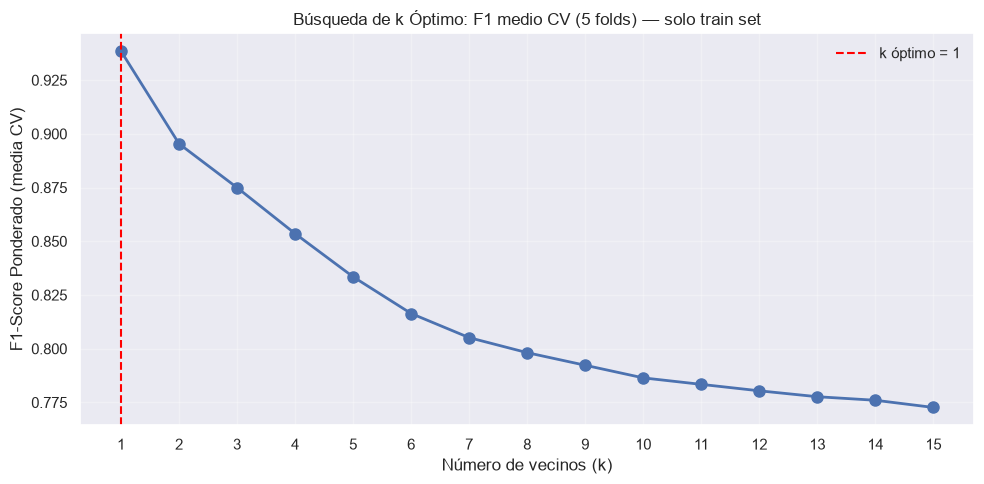


✓ k óptimo encontrado: 1
  F1-Score medio CV (train): 0.9385
  X_test no fue utilizado en este paso.


In [29]:
# ===== PASO 4: BÚSQUEDA DE k ÓPTIMO CON CROSS-VALIDATION =====
# Se evalúa con StratifiedKFold sobre X_train_balanced — X_test NO se toca aquí.
# Cada fold actúa como validación interna; el test set queda reservado para evaluación final.

k_range = range(1, 16)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    fold_f1 = []
    for train_idx, val_idx in cv.split(X_train_balanced, y_train_balanced):
        X_fold_train, y_fold_train = X_train_balanced[train_idx], y_train_balanced[train_idx]
        X_fold_val,   y_fold_val   = X_train_balanced[val_idx],   y_train_balanced[val_idx]
        knn.fit(X_fold_train, y_fold_train)
        y_fold_pred = knn.predict(X_fold_val)
        fold_f1.append(f1_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
    f1_scores.append(np.mean(fold_f1))

k_optimo_idx = np.argmax(f1_scores)
k_optimo = list(k_range)[k_optimo_idx]

plt.figure(figsize=(10, 5))
plt.plot(k_range, f1_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.title('Búsqueda de k Óptimo: F1 medio CV (5 folds) — solo train set')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('F1-Score Ponderado (media CV)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ k óptimo encontrado: {k_optimo}")
print(f"  F1-Score medio CV (train): {max(f1_scores):.4f}")
print(f"  X_test no fue utilizado en este paso.")


In [30]:
# ===== PASO 5: ENTRENAMIENTO FINAL CON k ÓPTIMO =====
# Entrenar SOLO con datos balanceados de TRAIN
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_train_balanced, y_train_balanced)

print(f"✓ Modelo KNN entrenado con k={k_optimo}")
print(f"  Datos de entrenamiento: {X_train_balanced.shape[0]} muestras")

✓ Modelo KNN entrenado con k=1
  Datos de entrenamiento: 18240 muestras


In [31]:
# ===== PASO 6: EVALUACIÓN EN TEST SET (sin data leakage) =====
# Predecir en TEST SET (datos que el modelo NUNCA vio)
y_pred_test = knn_final.predict(X_test)

# Calcular métricas robustas
accuracy = accuracy_score(y_test, y_pred_test)
precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET (Datos nuevos)")
print("="*60)
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (ponderado): {precision_weighted:.4f}")
print(f"Recall (ponderado):    {recall_weighted:.4f}")
print(f"F1-Score (ponderado):  {f1_weighted:.4f}")

print("="*60)
print("REPORTE DE CLASIFICACIÓN (Por clase):")
print(classification_report(y_test, y_pred_test, zero_division=0))



EVALUACIÓN EN TEST SET (Datos nuevos)
Accuracy:              0.7163
Precision (ponderado): 0.7140
Recall (ponderado):    0.7163
F1-Score (ponderado):  0.7127
REPORTE DE CLASIFICACIÓN (Por clase):
                                    precision    recall  f1-score   support

      ambientes_test_integraciones       0.69      0.65      0.67        31
                archivos_sftp_test       0.68      0.71      0.69        24
        banca_empresas_movimientos       0.91      0.97      0.94        64
 certificados_deposito_destruccion       0.74      0.81      0.77        63
          chequeras_gestion_rangos       0.89      0.82      0.85       120
        cheques_activos_devolucion       0.80      0.82      0.81       139
        cheques_devueltos_custodia       0.64      0.82      0.72        33
   cheques_emergencia_certificados       0.68      0.62      0.65        48
comprobantes_pignoracion_impresion       0.66      0.57      0.61        40
       consolidacion_productos_cif       0

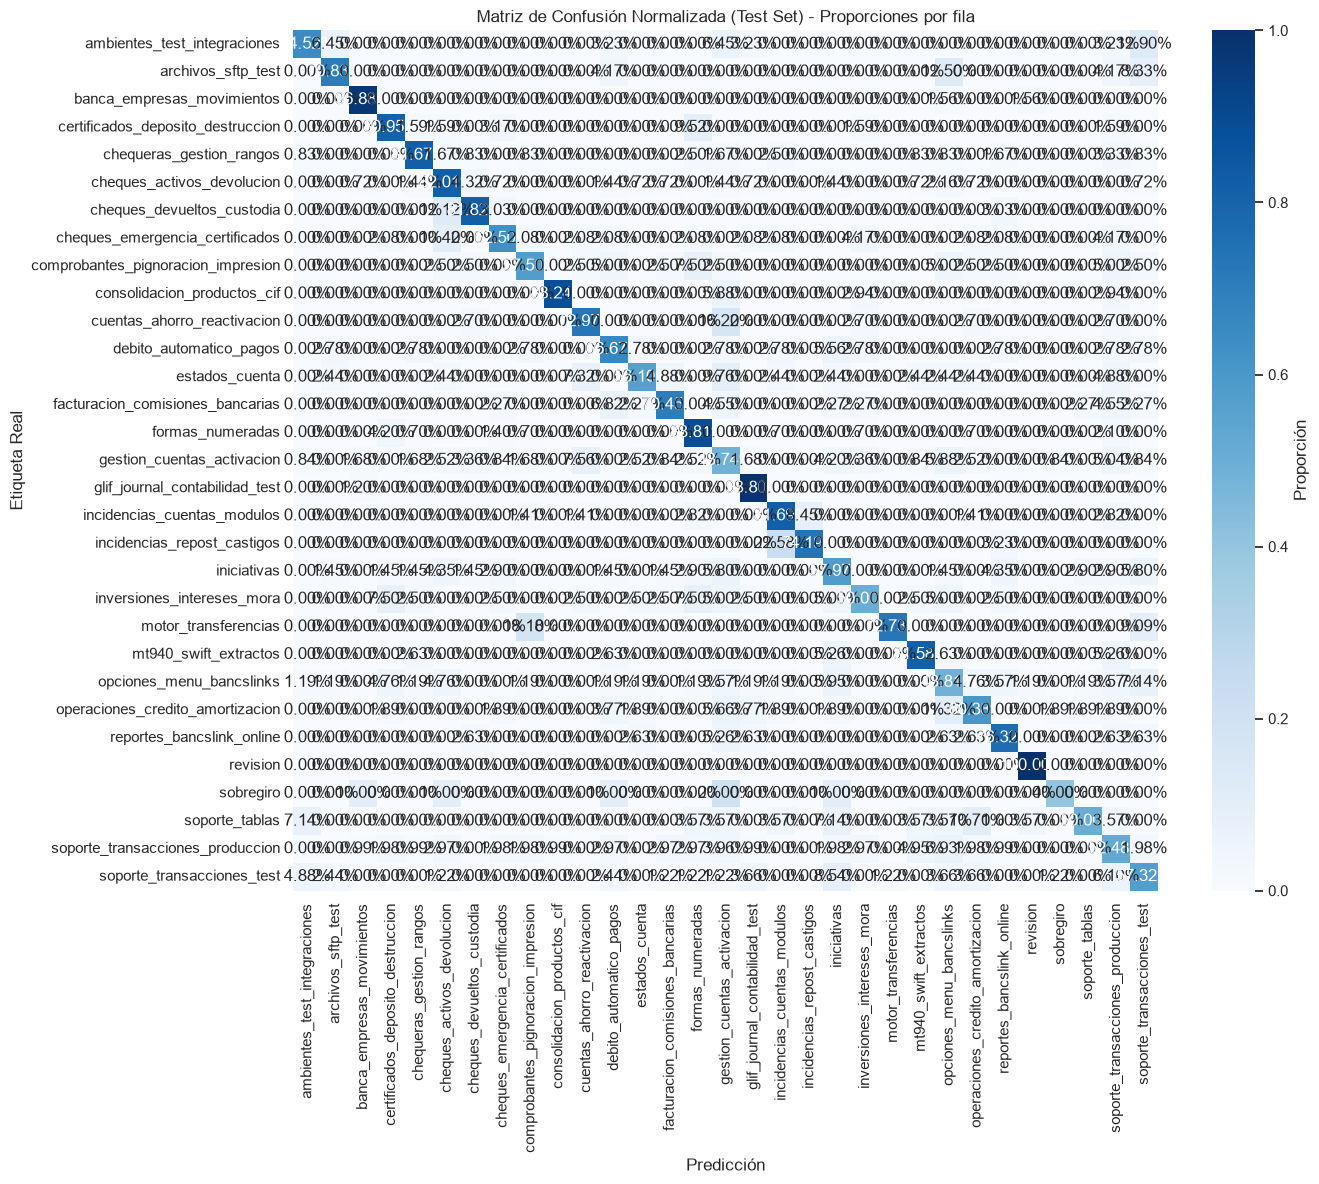

In [32]:
# Visualizar matriz de confusión normalizada
labels = sorted(list(set(list(y_test) + list(y_pred_test))))
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proporción'})
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Normalizada (Test Set) - Proporciones por fila')
plt.tight_layout()
plt.show()


## Comparativa de Clasificadores

### Random Forest

In [33]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

print("✓ Random Forest entrenado  (n_estimators=200)")


✓ Random Forest entrenado  (n_estimators=200)


### Logistic Regression

In [34]:
lr_model = LogisticRegression(C=1.0, max_iter=3000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_balanced, y_train_balanced)

print("✓ Logistic Regression entrenada  (C=1.0)")


✓ Logistic Regression entrenada  (C=1.0)


In [35]:

# ── Combinar los tres modelos y evaluar en test set ────────────────────────
modelos = {
    'KNN':                 knn_final,
    'Random Forest':       rf_model,
    'Logistic Regression': lr_model,
}

resultados = []
predicciones_modelos = {}
for nombre, modelo in modelos.items():
    y_pred_m = modelo.predict(X_test)
    predicciones_modelos[nombre] = y_pred_m
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred_m),
        'F1-Score':  f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Precision': precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred_m, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print("=== Métricas comparativas (conjunto de prueba) ===\n")
print(df_resultados.round(4).to_string())

mejor = df_resultados['F1-Score'].idxmax()
print(f"\n► Mejor clasificador por F1-Score (weighted): {mejor}  "
      f"({df_resultados.loc[mejor, 'F1-Score']:.4f})")


=== Métricas comparativas (conjunto de prueba) ===

                     Accuracy  F1-Score  Precision  Recall
Modelo                                                    
KNN                    0.7163    0.7127     0.7140  0.7163
Random Forest          0.8529    0.8512     0.8571  0.8529
Logistic Regression    0.8656    0.8655     0.8692  0.8656

► Mejor clasificador por F1-Score (weighted): Logistic Regression  (0.8655)


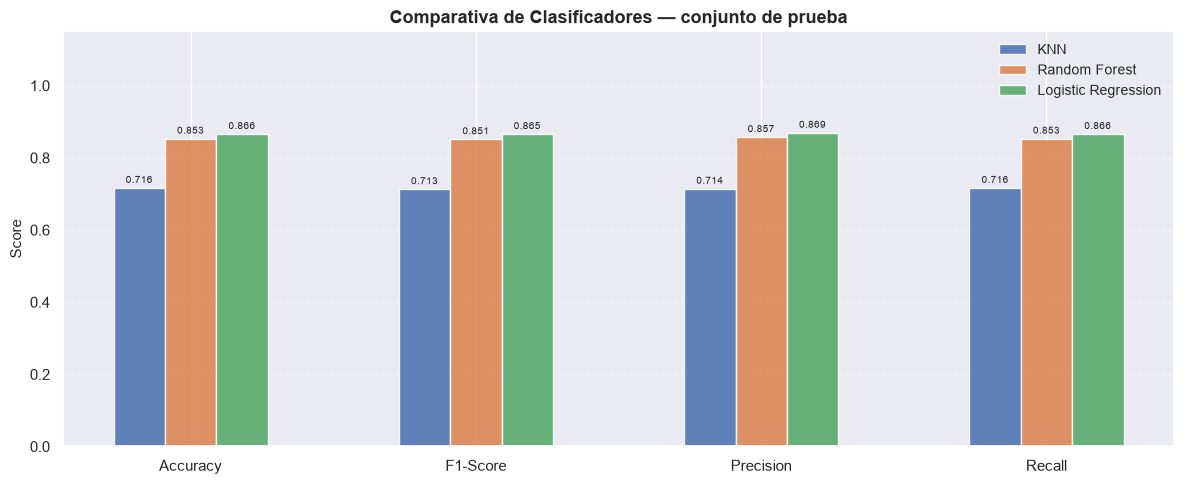

In [36]:
metricas = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metricas))
n_modelos = len(df_resultados)
ancho = 0.18
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.88)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

offset_centro = (n_modelos - 1) * ancho / 2
ax.set_xticks(x + offset_centro)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparativa de Clasificadores — conjunto de prueba', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


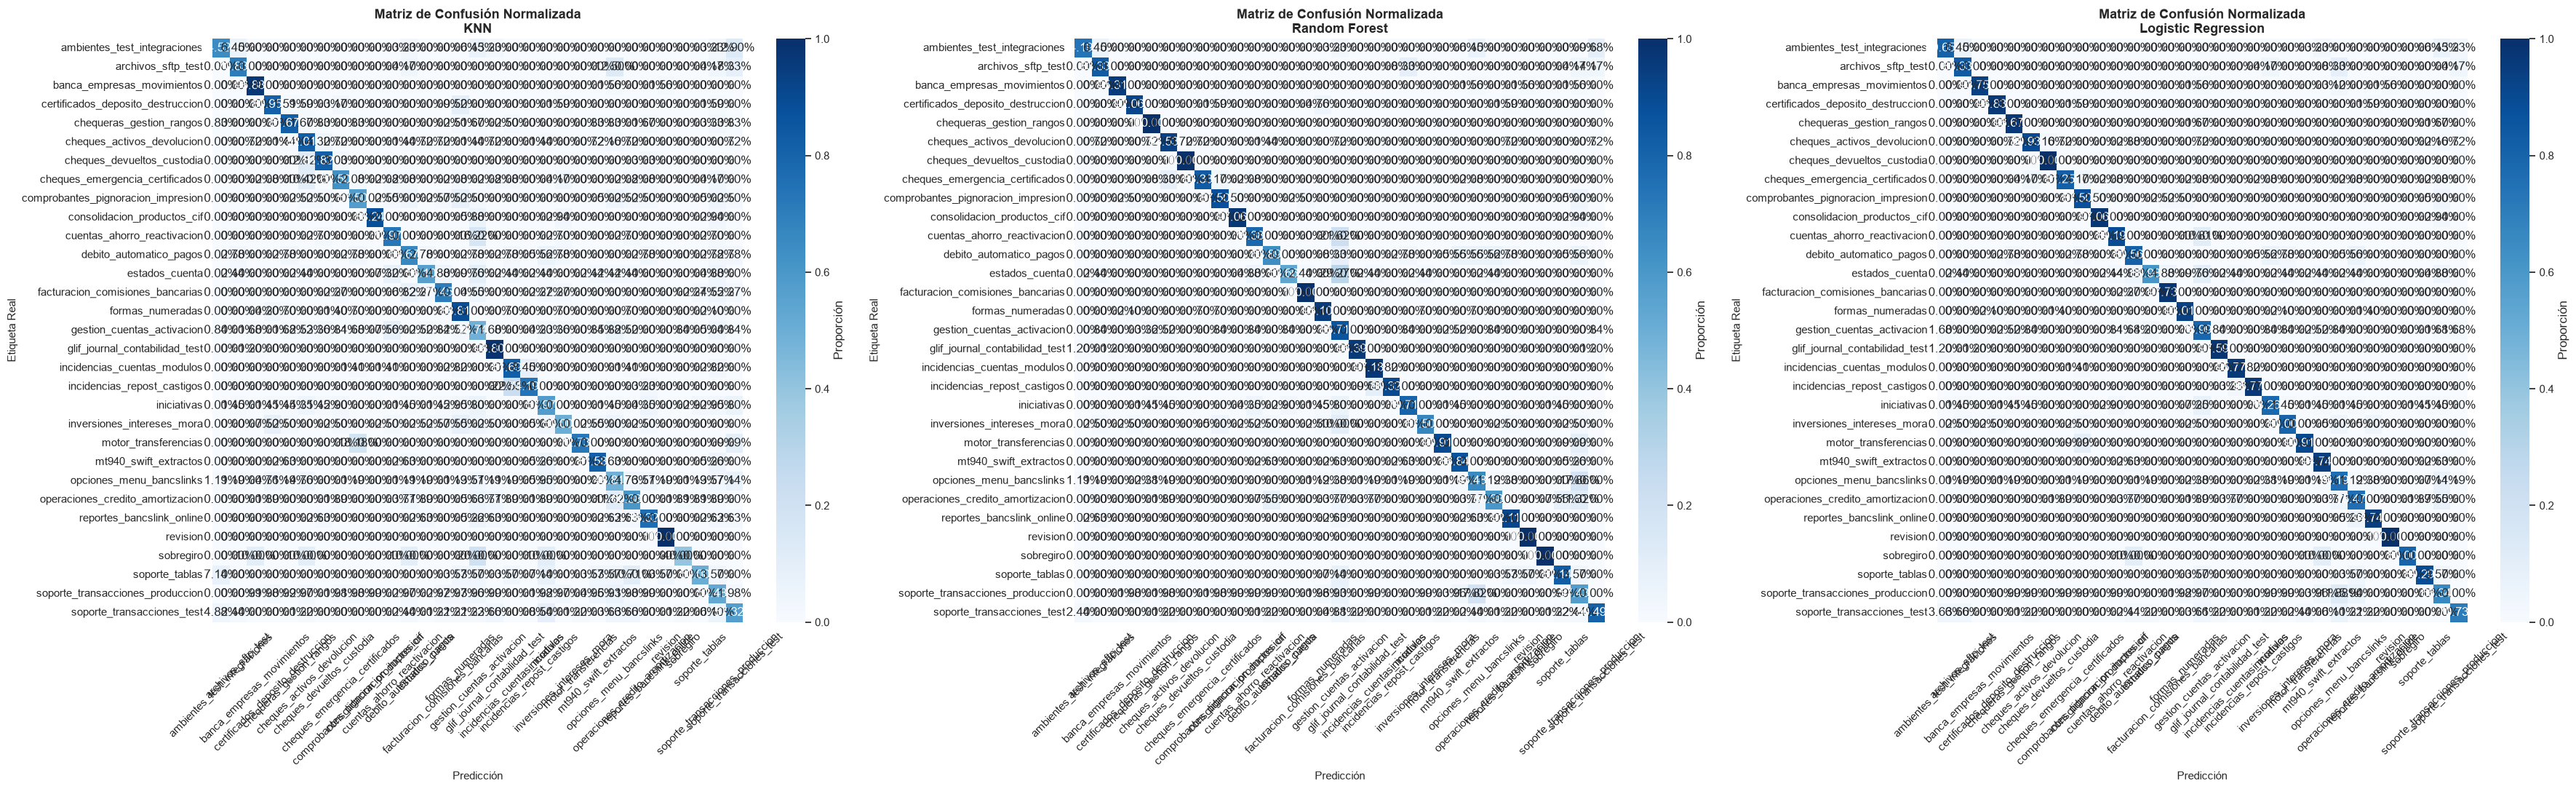

In [37]:
labels = sorted(list(set(list(y_test))))
fig, axes = plt.subplots(1, 3, figsize=(36, 11))

for ax, (nombre, y_pred_m) in zip(axes, predicciones_modelos.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Proporción'}, ax=ax
    )
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_title(f'Matriz de Confusión Normalizada\n{nombre}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## Análisis de Errores

### Detalle de errores — Logistic Regression

Total de errores en test set: 242 de 1801
Tasa de error: 13.44%
Accuracy: 0.8656

Top 15 confusiones más frecuentes:
                          y_real                       y_predicho  count
soporte_transacciones_produccion         opciones_menu_bancslinks     12
        opciones_menu_bancslinks soporte_transacciones_produccion      6
soporte_transacciones_produccion operaciones_credito_amortizacion      6
      gestion_cuentas_activacion                   estados_cuenta      5
      soporte_transacciones_test         opciones_menu_bancslinks      5
                     iniciativas       gestion_cuentas_activacion      5
      cheques_activos_devolucion          debito_automatico_pagos      4
                  estados_cuenta       gestion_cuentas_activacion      4
soporte_transacciones_produccion            mt940_swift_extractos      4
     cuentas_ahorro_reactivacion       gestion_cuentas_activacion      4
operaciones_credito_amortizacion soporte_transacciones_produccion      4
      g

,number,short_description,texto_unificado,y_real,y_predicho
23,RITM0845576,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink estimados favor solicito ayuda validando abonos real...,soporte_transacciones_produccion,operaciones_credito_amortizacion
28,RITM0387604,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink favor ayuda cheque gerencia generado valor cuenta cl...,cheques_emergencia_certificados,cuentas_ahorro_reactivacion
32,RITM0386793,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink campos aprobados bancs cuenta contable extraados tab...,soporte_tablas,soporte_transacciones_produccion
33,RITM0397654,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink buenos daas requerimiento deben canalizarlo mediante...,incidencias_cuentas_modulos,comprobantes_pignoracion_impresion
42,RITM0469114,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink ayuda cliente reylacteos solicita revision facturaci...,cheques_activos_devolucion,debito_automatico_pagos
47,RITM0161500,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink pruebas migracion servicio precenta error indico cor...,gestion_cuentas_activacion,ambientes_test_integraciones
55,RITM0902297,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink estimados favor apoyo requiere cerrar cuenta permite...,iniciativas,gestion_cuentas_activacion
61,RITM0653990,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink ayuda puedo ingresar poder sacvar tablas amortizacion,operaciones_credito_amortizacion,opciones_menu_bancslinks
68,RITM0417206,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink favor ayuda indique datos hoteles decameron ecuador ...,soporte_transacciones_produccion,mt940_swift_extractos
88,RITM0135057,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink,requerimientos relacionados bancs bancslink estimados buenas tardes favor gentil ayuda requerimo...,soporte_transacciones_test,reportes_bancslink_online


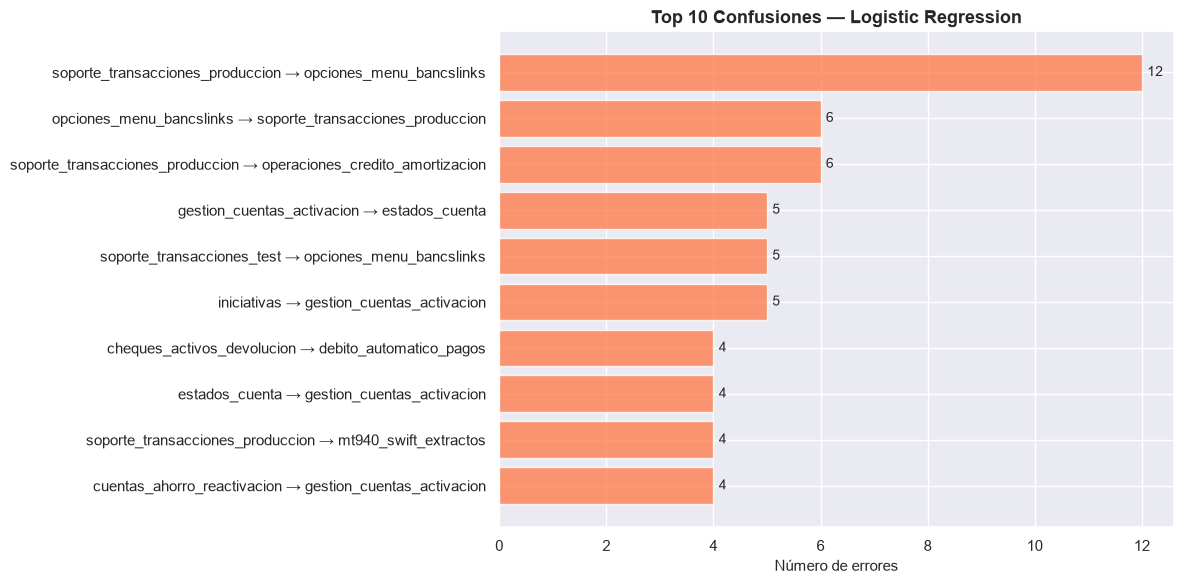

In [38]:
# ── Análisis detallado de errores — Logistic Regression ────────────────────

# Predecir en test set con Logistic Regression
y_pred_lr = lr_model.predict(X_test)

# Identificar muestras mal clasificadas
indices_errores = np.where(y_test != y_pred_lr)[0]
df_errores = df_test_base.iloc[indices_errores].copy()
df_errores['y_predicho'] = y_pred_lr[indices_errores]
df_errores['es_error'] = True

print(f"Total de errores en test set: {len(df_errores)} de {len(y_test)}")
print(f"Tasa de error: {len(df_errores) / len(y_test) * 100:.2f}%")
print(f"Accuracy: {1 - len(df_errores) / len(y_test):.4f}\n")

# Matriz de confusión de errores
print("Top 15 confusiones más frecuentes:")
confusiones = df_errores.groupby(['y_real', 'y_predicho']).size().reset_index(name='count')
confusiones = confusiones.sort_values('count', ascending=False).head(15)
print(confusiones.to_string(index=False))

# Mostrar ejemplos de errores por tipo
print("\n" + "="*80)
print("EJEMPLOS DE ERRORES (primeras 10 muestras mal clasificadas):")
print("="*80)

cols_error = [c for c in ['number', 'short_description', 'texto_unificado', 'y_real', 'y_predicho'] 
              if c in df_errores.columns]
with pd.option_context('display.max_colwidth', 100, 'display.max_rows', None):
    display(df_errores[cols_error].head(10))

# Gráfico: clases más confundidas
fig, ax = plt.subplots(figsize=(12, 6))
confusiones_top = confusiones.head(10)
barras = ax.barh(range(len(confusiones_top)), confusiones_top['count'], color='coral', alpha=0.8)
ax.set_yticks(range(len(confusiones_top)))
labels_y = [f"{row['y_real']} → {row['y_predicho']}" 
            for _, row in confusiones_top.iterrows()]
ax.set_yticklabels(labels_y)
ax.set_xlabel('Número de errores', fontsize=11)
ax.set_title('Top 10 Confusiones — Logistic Regression', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for barra, val in zip(barras, confusiones_top['count']):
    ax.text(val + 0.1, barra.get_y() + barra.get_height()/2, str(int(val)), 
            va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [39]:
# Tickets que presentan confusión (errores de clasificación en test)
# Usa df_errores generado en la celda de análisis de errores.

if 'df_errores' not in globals():
    raise ValueError("No existe 'df_errores'. Ejecuta primero la celda de análisis de errores.")

# Crear identificador de ticket si no existe la columna 'number'
if 'number' not in df_errores.columns:
    df_errores = df_errores.copy()
    df_errores['number'] = df_errores.index.astype(str)

print(f"Total de tickets con confusión: {len(df_errores)}")

# 1) Resumen por tipo de confusión (real -> predicho) con IDs de tickets
resumen_confusiones_tickets = (
    df_errores.groupby(['y_real', 'y_predicho'], as_index=False)
    .agg(
        total_tickets=('number', 'count'),
        tickets=('number', lambda x: ', '.join(x.astype(str).head(30)))
    )
    .sort_values('total_tickets', ascending=False)
)

print("\nTop confusiones con tickets asociados:")
display(resumen_confusiones_tickets)


Total de tickets con confusión: 242

Top confusiones con tickets asociados:


,y_real,y_predicho,total_tickets,tickets
126,soporte_transacciones_produccion,opciones_menu_bancslinks,12,"RITM0593909, RITM0763651, RITM0359495, RITM062..."
101,opciones_menu_bancslinks,soporte_transacciones_produccion,6,"RITM0756471, RITM0628296, RITM0229418, RITM088..."
127,soporte_transacciones_produccion,operaciones_credito_amortizacion,6,"RITM0845576, RITM0099894, RITM0637723, RITM060..."
59,gestion_cuentas_activacion,estados_cuenta,5,"RITM0720319, RITM0730387, RITM0285916, RITM062..."
137,soporte_transacciones_test,opciones_menu_bancslinks,5,"RITM0600224, RITM0191912, RITM0525793, RITM052..."
...,...,...,...,...
132,soporte_transacciones_test,estados_cuenta,1,RITM0857890
135,soporte_transacciones_test,iniciativas,1,RITM0060743
134,soporte_transacciones_test,glif_journal_contabilidad_test,1,RITM0116991
138,soporte_transacciones_test,operaciones_credito_amortizacion,1,RITM0165030


In [40]:
# Exportar a CSV el resumen y/o detalle de tickets con confusión

fecha_hoy = pd.Timestamp.today().strftime("%Y-%m-%d")
carpeta_output = 'Resultados'
os.makedirs(carpeta_output, exist_ok=True)

# 1) Resumen de confusiones (si existe)
resumen_confusiones = globals().get('resumen_confusiones_tickets')
if resumen_confusiones is not None:
    ruta_resumen = os.path.join(carpeta_output, f"resumen_confusiones_tickets_{fecha_hoy}.csv")
    resumen_confusiones.to_csv(ruta_resumen, index=False, encoding='utf-8-sig')
    print(f"✓ Resumen exportado: {ruta_resumen} ({len(resumen_confusiones)} filas)")

# 2) Detalle de tickets confundidos (si existe)
tickets_conf = globals().get('tickets_confundidos')
if tickets_conf is not None:
    ruta_detalle = os.path.join(carpeta_output, f"tickets_confundidos_{fecha_hoy}.csv")
    tickets_conf.to_csv(ruta_detalle, index=False, encoding='utf-8-sig')
    print(f"✓ Detalle exportado: {ruta_detalle} ({len(tickets_conf)} filas)")
elif 'df_errores' in globals():
    cols_detalle = [c for c in ['number', 'short_description', 'texto_unificado', 'y_real', 'y_predicho'] if c in df_errores.columns]
    detalle_tmp = df_errores[cols_detalle].sort_values(['y_real', 'y_predicho', 'number']).reset_index(drop=True)
    ruta_detalle = os.path.join(carpeta_output, f"tickets_confundidos_{fecha_hoy}.csv")
    detalle_tmp.to_csv(ruta_detalle, index=False, encoding='utf-8-sig')
    print(f"✓ Detalle exportado (desde df_errores): {ruta_detalle} ({len(detalle_tmp)} filas)")

✓ Resumen exportado: Resultados\resumen_confusiones_tickets_2026-07-26.csv (140 filas)
✓ Detalle exportado (desde df_errores): Resultados\tickets_confundidos_2026-07-26.csv (242 filas)


## Generación de csv tickets ya clasificados tras algoritmo

In [41]:
# ── Persistencia del modelo y vectorizer ─────────────────────────────────────
# Se guardan juntos en la carpeta 'modelo/' para garantizar que la
# transformación TF-IDF sea idéntica al momento de inferencia futura.
mejor_modelo = modelos[mejor] # <-- Línea añadida para solucionar el NameError
nombre_modelo = mejor.replace(' ', '_')

carpeta_modelo = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'semisupervised_model'))
os.makedirs(carpeta_modelo, exist_ok=True)

ruta_modelo     = os.path.join(carpeta_modelo, f'modelo_{nombre_modelo}.joblib')
ruta_vectorizer = os.path.join(carpeta_modelo, 'vectorizer_tfidf.joblib')

joblib.dump(mejor_modelo, ruta_modelo)
joblib.dump(vectorizer,   ruta_vectorizer)

print(f"✓ Modelo guardado:     {ruta_modelo}")
print(f"✓ Vectorizer guardado: {ruta_vectorizer}")
print()
print("Para cargar y usar en otro script:")
print(f"  modelo     = joblib.load('modelo/modelo_{nombre_modelo}.joblib')")
print(f"  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')")
print(f"  X_nuevo    = vectorizer.transform(textos_nuevos)")
print(f"  prediccion = modelo.predict(X_nuevo)")


✓ Modelo guardado:     z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\semisupervised_model\modelo_Logistic_Regression.joblib
✓ Vectorizer guardado: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\semisupervised_model\vectorizer_tfidf.joblib

Para cargar y usar en otro script:
  modelo     = joblib.load('modelo/modelo_Logistic_Regression.joblib')
  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')
  X_nuevo    = vectorizer.transform(textos_nuevos)
  prediccion = modelo.predict(X_nuevo)
